In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.

from tensorflow.keras.utils import to_categorical
# Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0]).


In [3]:
from sklearn.datasets import load_iris

np.random.seed(42)
iris = load_iris()

X = iris.data
y = iris.target

n = 10000
indices = np.random.choice(len(X), n, replace=True)

df = pd.DataFrame(
    X[indices],
    columns=[
        'SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm'
    ]
)

df += np.random.normal(0, 0.15, df.shape)

df['Species'] = iris.target_names[y[indices]]

df.insert(0, 'Id', range(1, n + 1))

print(df.head())
print(df.shape)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm     Species
0   1       7.059441      2.834299       5.641483      2.081845   virginica
1   2       5.646154      2.534523       4.218435      1.191923  versicolor
2   3       5.687431      4.046313       1.488143      0.181896      setosa
3   4       4.546671      2.597511       4.551965      1.713518   virginica
4   5       6.067123      2.678909       4.227246      1.024254  versicolor
(10000, 6)


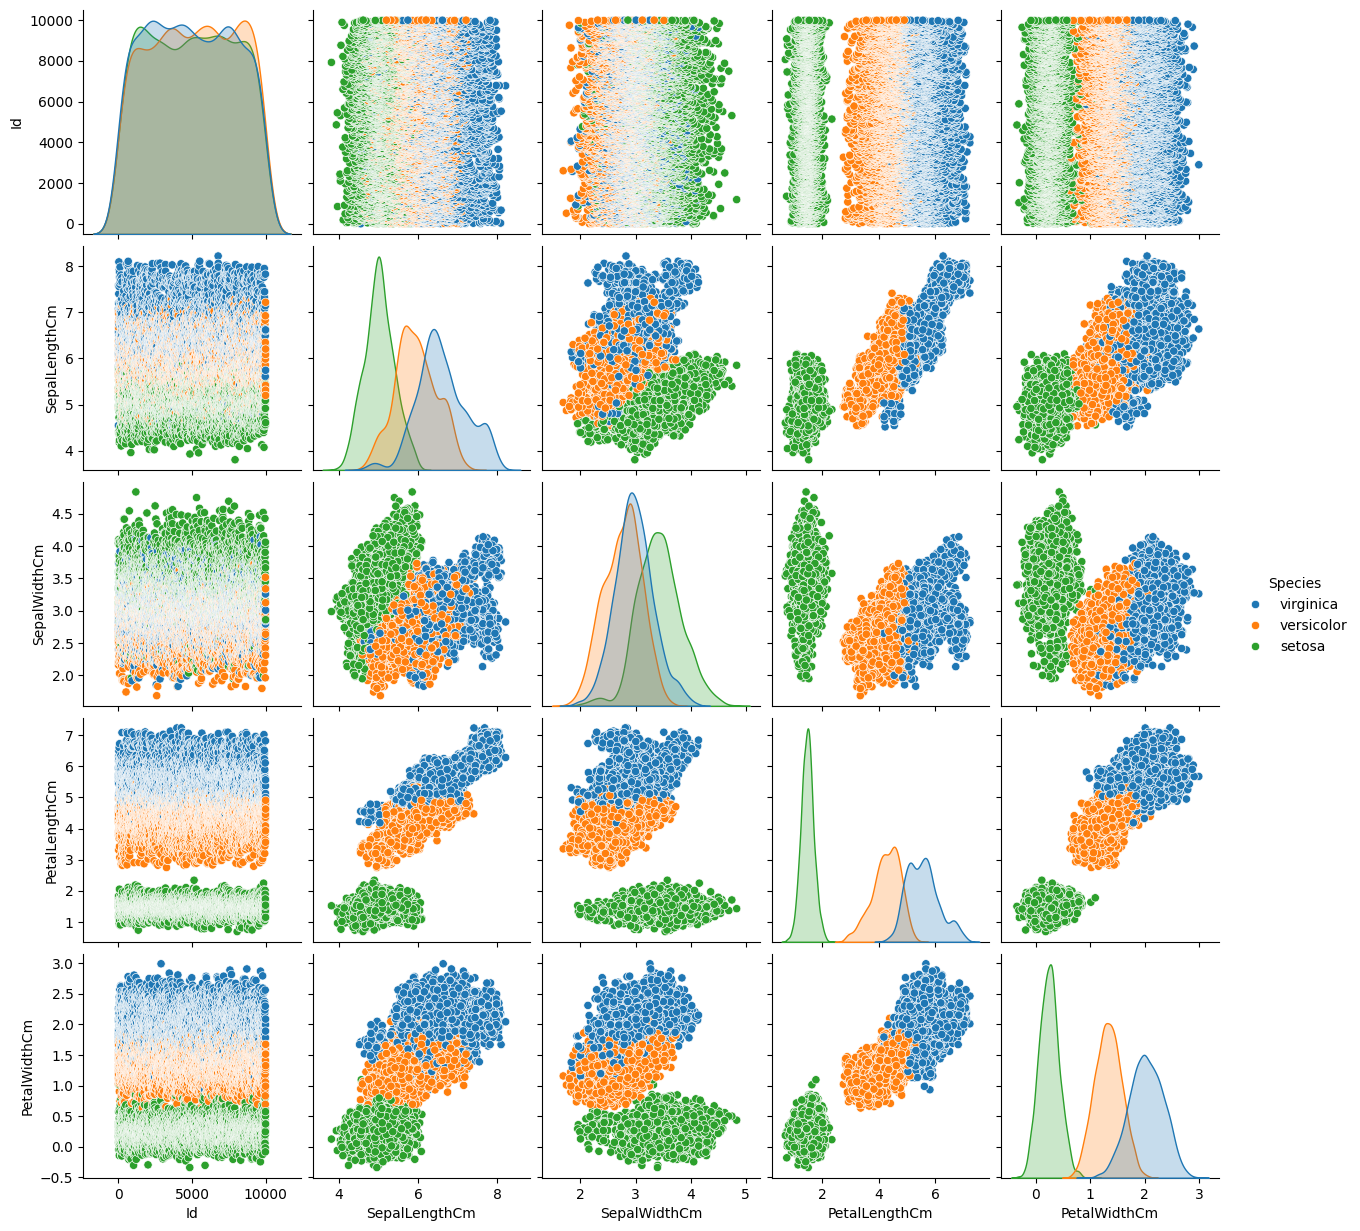

In [4]:
sns.pairplot(df, hue='Species')

In [5]:
X = df.drop(columns=['Species', 'Id'], axis = 1)
y = df['Species']

In [8]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

array([2, 1, 0, ..., 1, 0, 1])

In [9]:
y_encoded

[2 1 0 ... 1 0 1]


In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42, stratify=y_encoded)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Using Perceptron - Single layer Model

In [27]:
per = Perceptron(random_state=42)
per.fit(X_train_scaled, y_train)

Perceptron(random_state=42)

In [28]:
y_pred_per = per.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred_per)
print(f"Accuracy of Perceptron: {acc}")

Accuracy of Perceptron: 0.8645


# Using ANN Model - Multi-Layer Model

In [29]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [30]:
model = Sequential([
    Dense(16,input_dim = 4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])

In [31]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [32]:
history = model.fit(X_train_scaled,y_train_cat,
                    epochs = 20,batch_size= 40, validation_split = 0.2,verbose = 1)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6095 - loss: 0.7071 - val_accuracy: 0.8000 - val_loss: 0.4604
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8402 - loss: 0.3601 - val_accuracy: 0.8763 - val_loss: 0.2819
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9191 - loss: 0.2226 - val_accuracy: 0.9569 - val_loss: 0.1658
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9545 - loss: 0.1466 - val_accuracy: 0.9638 - val_loss: 0.1152
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9603 - loss: 0.1138 - val_accuracy: 0.9731 - val_loss: 0.0924
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9641 - loss: 0.0983 - val_accuracy: 0.9731 - val_loss: 0.0821
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.0902 - val_accuracy: 0.9719 - val_loss: 0.0766
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9659 - loss: 0.0861 - val_accuracy: 0.

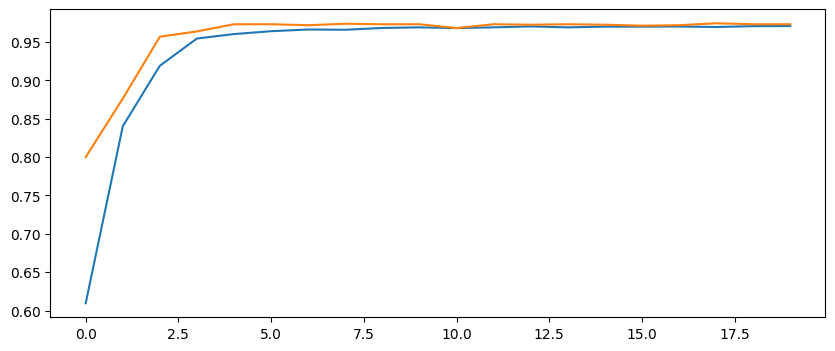

In [33]:
plt.figure(figsize = (10,4))
plt.plot(history.history['accuracy'],label = "train Acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")